# Baseline Training Notebook - Telemetry Heart AI

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('../app/data/heart.csv')
print(f"Dataset shape: {df.shape}")

# Prepare features
X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Dataset shape: (303, 14)


In [3]:
# Train RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [4]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8852
Precision: 0.8387
Recall: 0.9286
F1-score: 0.8814


In [5]:
# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV Accuracy: 0.8215 (+/- 0.0436)


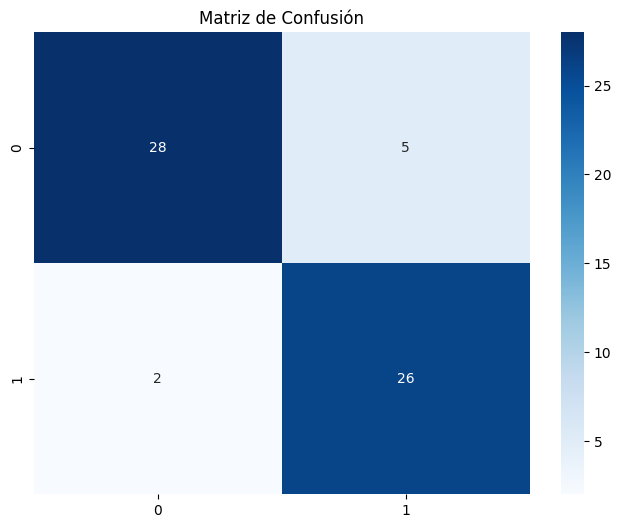

In [6]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusi\u00f3n')
plt.show()

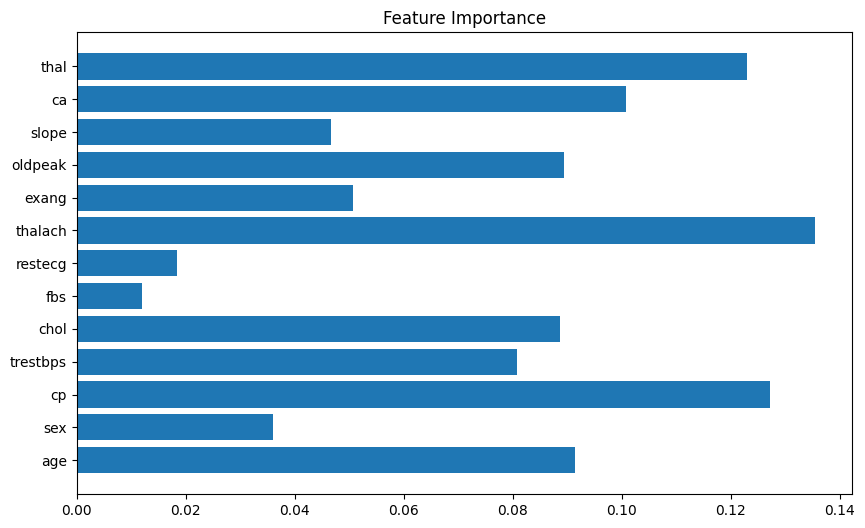

In [7]:
# Feature importance
features = X.columns
importances = model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title('Feature Importance')
plt.show()

In [8]:
# Save model
joblib.dump(model, '../app/data/model.pkl')
print("[OK] Model saved to ../data/model.pkl")

# Save metrics
metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std()
}
print("Baseline Metrics:", metrics)

[OK] Model saved to ../data/model.pkl
Baseline Metrics: {'accuracy': 0.8852459016393442, 'precision': 0.8387096774193549, 'recall': 0.9285714285714286, 'f1_score': 0.8813559322033898, 'cv_mean': np.float64(0.8214754098360656), 'cv_std': np.float64(0.043563121196517264)}
